In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# set WD to /gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022 
os.chdir('/gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022')

# read cells file Cell_annotation.csv
cells = pd.read_csv('Cell_annotation.csv', index_col=0)

In [2]:
cells.head()

,Cell_shortDT,UMI_count,Gene_count,PCR_sample_name,Ligation_barcode,RT_barcode_random_hexamer,RT_barcode_shortDT,umap_1,umap_2,Louvain_cluster,Type,Sex,Replicate_ID,Main_cluster_name,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num
Cell_random_hexamer,,,,,,,,,,,,,,,,,,
EasySci_001.AACCGATTGCATGCAATATG,EasySci_001.AACCGATTGCAATCGAACTC,558,379,EasySci_001,AACCGATTGC,ATGCAATATG,AATCGAACTC,0.345946,4.792399,7,5xFAD,male,1,Cerebellum granule neurons,Cerebellum granule neurons_1,1.337663,-3.196105,1.0
EasySci_001.AACCGATTGCTTAGCAATAA,EasySci_001.AACCGATTGCACTCCGCCAA,3180,1371,EasySci_001,AACCGATTGC,TTAGCAATAA,ACTCCGCCAA,7.559918,-3.935702,6,3mo,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_1,-0.875215,-2.433680,1.0
EasySci_001.AACCGATTGCAGCTAAGGTA,EasySci_001.AACCGATTGCAGCGATCCGC,3132,1657,EasySci_001,AACCGATTGC,AGCTAAGGTA,AGCGATCCGC,8.763198,-3.253150,31,6mo,male,1,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_2,2.808076,3.226601,2.0
EasySci_001.AACCGATTGCTCTCCTATAA,EasySci_001.AACCGATTGCCATCCAGCCA,10028,3436,EasySci_001,AACCGATTGC,TCTCCTATAA,CATCCAGCCA,7.853685,-3.673076,30,APOE4/TREM2,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_3,1.555948,0.093578,3.0
EasySci_001.AACCGATTGCCGCCTCGAAC,EasySci_001.AACCGATTGCCCAGGCTCTT,953,610,EasySci_001,AACCGATTGC,CGCCTCGAAC,CCAGGCTCTT,-7.504099,0.636785,47,6mo,male,1,Oligodendrocyte progenitor cells,Oligodendrocyte progenitor cells_1,3.020408,-0.754258,1.0


In [8]:
cells.Main_cluster_name.unique()

array(['Cerebellum granule neurons', 'Interbrain and midbrain neurons 2',
       'Oligodendrocyte progenitor cells', 'Striatal neurons 1',
       'Oligodendrocytes', 'Astrocytes', 'OB neurons 1',
       'Ependymal cells', 'Purkinje neurons', 'Dentate gyrus neurons',
       'Interbrain and midbrain neurons 1', 'Hindbrain neurons 2',
       'Cerebellum interneurons', 'Interneurons 1', 'Interneurons 2',
       'Cortical projection neurons 1', 'Habenula neurons',
       'Cortical projection neurons 2', 'Endothelial cells', 'Microglia',
       'Choroid plexus epithelial cells', 'Bergmann glia',
       'Inferior olivary nucleus neurons', 'Pituitary cells',
       'Vascular leptomeningeal cells', 'OB neurons 2',
       'Striatal neurons 2', 'Cortical projection neurons 3',
       'Hindbrain neurons 1', 'Unipolar brush cells', 'OB neurons 3'],
      dtype=object)

In [17]:
# let's filter to just astrocytes 
astrocytes = cells[cells['Main_cluster_name'] == 'Astrocytes']

# get breakdown of astrocytes by mouse Type and Sex 
astro = astrocytes[['Type', 'Sex']].value_counts()
astro

Type         Sex   
APOE4/TREM2  female    9494
6mo          male      8592
APOE4/TREM2  male      8387
3mo          male      7370
             female    7170
6mo          female    5882
5xFAD        male      5821
21mo         female    5680
             male      4723
5xFAD        female    3264
dtype: int64

In [25]:
astro.sum()

66383

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '(APOE4/TREM2, female)'),
  Text(1, 0, '(6mo, male)'),
  Text(2, 0, '(APOE4/TREM2, male)'),
  Text(3, 0, '(3mo, male)'),
  Text(4, 0, '(3mo, female)'),
  Text(5, 0, '(6mo, female)'),
  Text(6, 0, '(5xFAD, male)'),
  Text(7, 0, '(21mo, female)'),
  Text(8, 0, '(21mo, male)'),
  Text(9, 0, '(5xFAD, female)')])

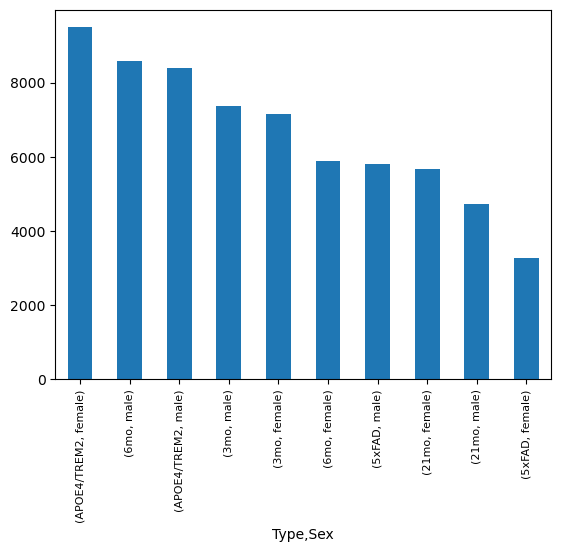

In [24]:
# make barplot of astro angle x-axis labels at 45 degrees and decrease font
astro.plot(kind='bar')
plt.xticks(fontsize=8)


In [15]:
# read in the cluster counts we got -> astrocytes_clusters_anno_free_50_500000_2_2_0.01_single_cell.gz
min_junc_reads_2 = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci/Leaflet/astrocytes_clusters_anno_free_50_500000_2_2_0.01_single_cell.gz', sep='}', index_col=0)
min_junc_reads_5 = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci/Leaflet/astrocytes_clusters_anno_free_50_500000_5_2_0.01_single_cell.gz', sep='}', index_col=0)

In [16]:
min_junc_reads_2.head()

,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,num_cells_wjunc,cell_readcounts,block_add_start,block_subtract_end,intron_length,cell_type,junction_id,Cluster,Count
chrom,,,,,,,,,,,,,,,,,,,,
1,7233595,7239738,JUNC000000560,4,+,7233540,7239827,"255,0,0",2,"55,89","0,6198",4,"EasySci_122.TGCCTTCCTACCGCTGCCAG:1,EasySci_003...",55,89,6143,Astrocytes_APOE4_female_cell,1_7233595_7239738,49,2
1,10153783,10158275,JUNC000001060,2,+,10153725,10158303,"255,0,0",2,"58,28","0,4550",2,"EasySci_093.TATACCGAAGTTCCATGGCA:1,EasySci_140...",58,28,4492,Astrocytes_APOE4_female_cell,1_10153783_10158275,79,3
1,11150348,11159940,JUNC000001600,39,+,11150255,11160027,"255,0,0",2,"93,87","0,9685",38,"EasySci_074.ATAATCGCGGCCATCGCGAA:1,EasySci_170...",93,87,9592,Astrocytes_APOE4_female_cell,1_11150348_11159940,101,3
1,13226759,13230384,JUNC000002210,4,-,13226694,13230482,"255,0,0",2,"65,98","0,3690",4,"EasySci_189.GCAGCTGATTCGATTACGGC:1,EasySci_058...",65,98,3625,Astrocytes_APOE4_female_cell,1_13226759_13230384,2763,2
1,14353422,14372993,JUNC000002590,5,-,14353353,14373079,"255,0,0",2,"69,86","0,19640",3,"EasySci_117.CATACCGGCGTTGCTAACGG:1,EasySci_061...",69,86,19571,Astrocytes_APOE4_female_cell,1_14353422_14372993,2803,3


In [37]:
min_junc_reads_2[min_junc_reads_2["junction_id"] == "1_11150348_11159940"]

,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,num_cells_wjunc,cell_readcounts,block_add_start,block_subtract_end,intron_length,cell_type,junction_id,Cluster,Count
chrom,,,,,,,,,,,,,,,,,,,,
1,11150348,11159940,JUNC000001600,39,+,11150255,11160027,"255,0,0",2,"93,87","0,9685",38,"EasySci_074.ATAATCGCGGCCATCGCGAA:1,EasySci_170...",93,87,9592,Astrocytes_APOE4_female_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000000860,10,+,11150272,11160024,"255,0,0",2,"76,84","0,9668",10,"EasySci_040.TTGGACCTATGGCATAGCTT:1,EasySci_180...",76,84,9592,Astrocytes_21mo_female_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000001052,12,+,11150269,11160027,"255,0,0",2,"79,87","0,9671",12,"EasySci_065.GATGCTACGATTCCTAGACC:1,EasySci_073...",79,87,9592,Astrocytes_21mo_male_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000001172,17,+,11150257,11160034,"255,0,0",2,"91,94","0,9683",17,"EasySci_080.TCTCATTGCCACGCCGTTCA:1,EasySci_129...",91,94,9592,Astrocytes_5xFAD_male_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000001483,31,+,11150255,11160029,"255,0,0",2,"93,89","0,9685",30,"EasySci_115.GCTAGTTGACGCCAACGCCA:1,EasySci_040...",93,89,9592,Astrocytes_6mo_male_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000001173,23,+,11150257,11160029,"255,0,0",2,"91,89","0,9683",23,"EasySci_092.GAAGACTGCCATATTGATAC:1,EasySci_028...",91,89,9592,Astrocytes_3mo_female_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000001403,36,+,11150257,11160034,"255,0,0",2,"91,94","0,9683",34,"EasySci_136.GTCGGCCGGTCTTGATTGCC:1,EasySci_147...",91,94,9592,Astrocytes_6mo_female_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000000780,13,+,11150250,11160014,"255,0,0",2,"98,74","0,9690",12,"EasySci_183.GGCGAGCTGGCCTGACGTTC:1,EasySci_076...",98,74,9592,Astrocytes_5xFAD_female_cell,1_11150348_11159940,101,3
1,11150348,11159940,JUNC000001724,46,+,11150250,11160034,"255,0,0",2,"98,94","0,9690",41,"EasySci_066.TGAGGTCGGTCGCCTAATGC:1,EasySci_128...",98,94,9592,Astrocytes_APOE4_male_cell,1_11150348_11159940,101,3


Text(0.5, 1.0, 'Histogram of junctions with at least 2 junction reads')

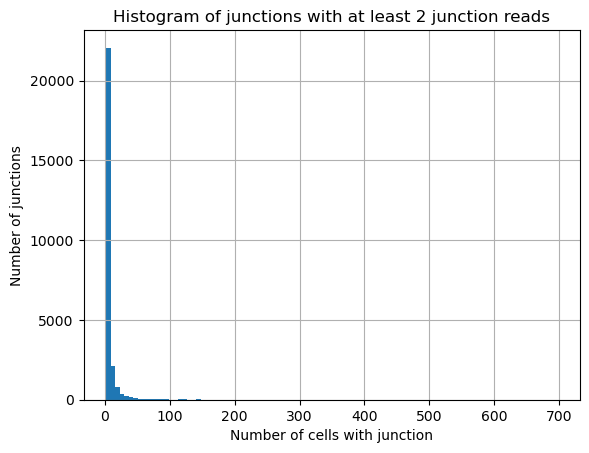

In [31]:
# make histogram using the num_cells_wjunc column and then also with the score column and also one for intron_length
min_junc_reads_2['num_cells_wjunc'].hist(bins=100)
plt.xlabel('Number of cells with junction')
plt.ylabel('Number of junctions')
plt.title('Histogram of junctions with at least 2 junction reads')
# plt.xlim(0,200)

Text(0.5, 1.0, 'Histogram of junctions with at least 2 junction reads')

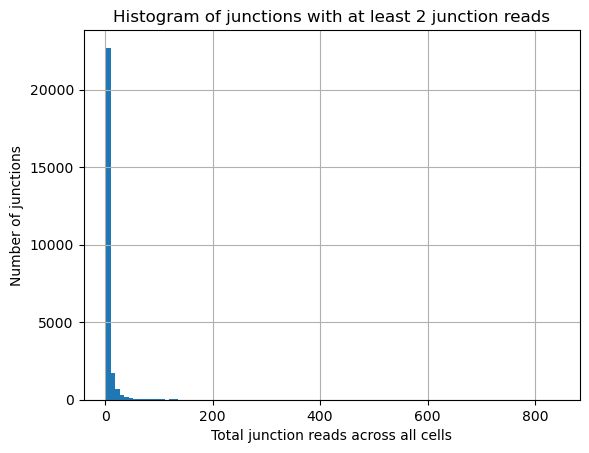

In [35]:
min_junc_reads_2['score'].hist(bins=100)
plt.xlabel('Total junction reads across all cells')
plt.ylabel('Number of junctions')
plt.title('Histogram of junctions with at least 2 junction reads')
#plt.xlim(0,200)

Text(0.5, 1.0, 'Histogram of junctions with at least 2 junction reads')

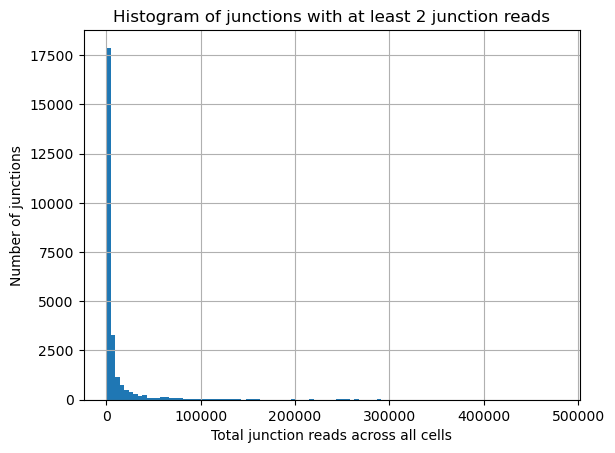

In [36]:
min_junc_reads_2['intron_length'].hist(bins=100)
plt.xlabel('Total junction reads across all cells')
plt.ylabel('Number of junctions')
plt.title('Histogram of junctions with at least 2 junction reads')
#plt.xlim(0,200)